## Pathway enrichment (ORA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
import pandas as pd
import ma_codes as codes
from ma_codes import mysize, gray_red, mymap
import pertpy as pt
import seaborn as sns
from pathlib import Path
import math
import re
import gseapy as gp

try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-13 12:12.


In [2]:
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# Endothelial cells in endothelial compartments
dge_folder_mild   = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Mild_Control/"
dge_folder_severe = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Severe_Control/"

## LEC

In [4]:
cell_type_filename = "diffExpResults_LEC.xlsx"
out_base = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/MAST_EC_pathway/new/LEC/"

ct_label   = "LEC"
ct_color   = "#e0e093"
pval_thresh = 0.05
lfc_thresh  = 0.3
TOP_N_LABEL = 20
#GENE_SETS   = ['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020']

In [5]:
# load DGE table
def load_dge(folder, fname):
    df = pd.read_excel(Path(folder) / fname)
    df = df.rename(columns={"Unnamed: 0": "gene"})
    return df

# Get up/down regulated gene list: p<0.05, |log2FC|>0.5
def get_up_down_genes(df, pval_col="p_val", lfc_col="avg_log2FC",
                       pval_thresh=0.05, lfc_thresh=0.5):
    sub = df.dropna(subset=[pval_col, lfc_col, "gene"])
    up = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] > lfc_thresh)]["gene"].tolist()
    down = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] < -lfc_thresh)]["gene"].tolist()
    return up, down

# pathway enrichment
def run_enrichr_up_down(glist_up, glist_down, outdir_up, outdir_down):
    enr_up = gp.enrichr(
        gene_list=glist_up,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,  # p value
        outdir=outdir_up,
        no_plot=True,
    )
    enr_down = gp.enrichr(
        gene_list=glist_down,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,
        outdir=outdir_down,
        no_plot=True,
    )
    return enr_up, enr_down

# load enrichment result
def load_results(outdir, gene_set):
    return pd.read_csv(Path(outdir) / f"{gene_set}.Human.enrichr.reports.txt", delimiter="\t")

# ── enrichment bar plot
def make_barplot(go_df, msig_df, go_idx, msig_idx, title, savepath=None,
                  figsize=(2, 3), palette="Reds"):
    go_sel = go_df.iloc[go_idx]
    msig_sel = msig_df.iloc[msig_idx]

    selection = pd.concat([msig_sel, go_sel], axis=0)
    selection["-log10(p_adj)"] = selection["Adjusted P-value"].apply(lambda x: -math.log10(x))
    selection.sort_values(by="-log10(p_adj)", ascending=False, inplace=True)

    fig, ax = plt.subplots()
    fig.set_size_inches(*figsize)
    sns.barplot(
        selection, x="-log10(p_adj)", y="Term", orient="y",
        hue="Gene_set", palette=palette,
        hue_order=["GO_Biological_Process_2025", "MSigDB_Hallmark_2020"]
    )
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.title(title, loc='center')
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    return fig, selection

# ── volcano plot ───────────────────────────────────────────────────────────────
def plot_volcano(
    df,
    condition,
    savepath=None,
    save=True,
    show=True,
    pval_col="p_val",
    lfc_col="avg_log2FC",
    figsize=(5, 4.5)
):
    df = df.dropna(subset=[pval_col, lfc_col, "gene"]).copy()

    df["-log10p"] = -np.log10(df[pval_col].clip(lower=1e-300))

    def status(r):
        if r[pval_col] < pval_thresh and r[lfc_col] > lfc_thresh:
            return "up"
        if r[pval_col] < pval_thresh and r[lfc_col] < -lfc_thresh:
            return "down"
        return "ns"

    df["status"] = df.apply(status, axis=1)

    n_up = (df["status"] == "up").sum()
    n_down = (df["status"] == "down").sum()

    color_map = {"up": ct_color, "down": "#4477AA", "ns": "#cccccc"}
    size_map = {"up": 18, "down": 18, "ns": 4}
    alpha_map = {"up": 0.85, "down": 0.85, "ns": 0.3}

    fig, ax = plt.subplots(figsize=figsize)

    for s in ["ns", "down", "up"]:
        sub = df[df["status"] == s]

        ax.scatter(
            sub[lfc_col],
            sub["-log10p"],
            s=size_map[s],
            c=color_map[s],
            alpha=alpha_map[s],
            linewidths=0,
            zorder=1 if s == "ns" else 3,
            rasterized=(s == "ns"),
        )

    ax.axhline(-np.log10(pval_thresh), color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(-lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(0, color="#444444", lw=0.5, ls="-", zorder=2)

    top = pd.concat([
        df[df["status"] == "up"].nlargest(TOP_N_LABEL, "-log10p"),
        df[df["status"] == "down"].nlargest(TOP_N_LABEL, "-log10p"),
    ])

    texts = [
        ax.text(
            r[lfc_col],
            r["-log10p"],
            r["gene"],
            fontsize=6.5,
            color="#222222",
        )
        for _, r in top.iterrows()
    ]

    if HAS_ADJUSTTEXT:
        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.5),
        )

    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    ax.text(
        xlim[1] * 0.97,
        ylim[1] * 0.97,
        f"Up: {n_up}",
        ha="right",
        va="top",
        fontsize=8,
        color=ct_color,
        fontweight="bold",
    )

    ax.text(
        xlim[0] * 0.97,
        ylim[1] * 0.97,
        f"Down: {n_down}",
        ha="left",
        va="top",
        fontsize=8,
        color="#4477AA",
        fontweight="bold",
    )

    ax.set_xlabel("log2 Fold Change", fontsize=10)
    ax.set_ylabel("–log10(p value)", fontsize=10)

    ax.set_title(
        f"{ct_label} — {condition}\n"
        f"threshold: p < {pval_thresh}, |log2FC| > {lfc_thresh}",
        fontsize=9,
        fontweight="bold",
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

    plt.tight_layout()

    if save:
        if savepath is None:
            raise ValueError("savepath must be provided when save=True")

        plt.savefig(savepath, bbox_inches="tight", dpi=300)
        print(f"  Saved: {Path(savepath).name}")

    if show:
        plt.show()

    plt.close(fig)

## Mild vs control

In [6]:
df_mild = load_dge(dge_folder_mild, cell_type_filename)
df_mild.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Mild,mean_Control
0,XIST,7503.0,1.021294e-16,0.931038,0.500,0.276,3.178779e-12,0.798755,0.495275
1,SMIM19,114926.0,5.325559e-12,0.153431,0.045,0.033,1.657580e-07,0.043590,0.040703
2,NRXN3,9369.0,9.494572e-11,1.274112,0.520,0.285,2.955186e-06,1.142203,0.631966
3,CMTM8,152189.0,1.613886e-10,0.837929,0.059,0.039,5.023219e-06,0.067011,0.037850
4,TFPI,7035.0,4.840844e-10,1.006156,0.921,0.763,1.506713e-05,1.814599,1.269160


In [7]:
glist_mild_up, glist_mild_down = get_up_down_genes(df_mild, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Mild vs Control DEGs— up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")

Mild vs Control DEGs— up: 858, down: 230


In [8]:
print(glist_mild_up)

['XIST', 'NRXN3', 'CMTM8', 'TFPI', 'FBXW5', 'MTSS2', 'TMED8', 'APP', 'NEAT1', 'SEMA3A', 'TXNDC15', 'COMMD4', 'CCL21', 'ITGA9', 'PPM1L', 'TGOLN2', 'SASH1', 'BRD3', 'AL122035.1', 'SPCS1', 'ZNF521', 'MMP16', 'AL078604.4', 'CSRNP2', 'SPRY4-AS1', 'EP300', 'PANK2', 'NOX4', 'AC005037.1', 'ELP1', 'UNC5B', 'AP000525.1', 'SPCS3', 'PHC1', 'KRAS', 'CEACAM19', 'LINC02802', 'OSBP2', 'MKRN1', 'KLHL2', 'SRSF4', 'RANBP10', 'ADAMTS15', 'NOCT', 'NINL', 'VDAC1', 'WDYHV1', 'TSC2', 'GRAP', 'CATSPERB', 'SLC25A51', 'RELN', 'CXorf38', 'HIF3A', 'BTN3A3', 'INAFM1', 'ATP11A', 'DPAGT1', 'GPM6B', 'EPHB1', 'HACD1', 'PRPF8', 'REEP1', 'PRKG1', 'KANSL1', 'ZNF276', 'PRKCA', 'SYNJ2', 'NFE2L2', 'ROBO4', 'RASAL2', 'GNG12', 'AC011824.2', 'OLFML2A', 'CASTOR3', 'SCARF1', 'RNF130', 'AL021368.2', 'ZMIZ1', 'CTTNBP2NL', 'AC130324.2', 'SV2B', 'RBM3', 'SRI', 'FAM221A', 'TXNL4B', 'REC114', 'SLC35D1', 'EMID1', 'FDFT1', 'DIPK2B', 'FLRT2', 'TFB1M', 'ZNF461', 'CTR9', 'TOR1AIP2', 'ZNF720', 'PGGT1B', 'GBA2', 'PIK3R3', 'ZFAND3', 'NEB', 'ST

  Saved: volcano_LEC_mild_vs_control.pdf


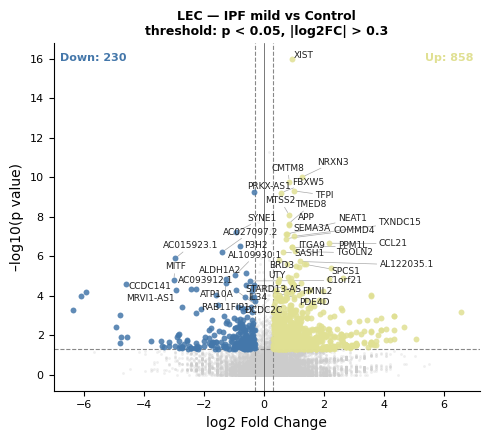

In [9]:
plot_volcano(df_mild, "IPF mild vs Control", save =True, show = True,
             savepath=out_base +"volcano_LEC_mild_vs_control.pdf")

In [10]:
enr_mild_up, enr_mild_down = run_enrichr_up_down(
    glist_mild_up, glist_mild_down,
    outdir_up=f"{out_base}/mild_up",
    outdir_down=f"{out_base}/mild_down",
)

### Upregulated pathways

In [11]:
GO_mild_up   = load_results(f"{out_base}/mild_up", "GO_Biological_Process_2025")
GO_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Axonogenesis (GO:0007409),22/200,0.000051,0.143737,0,0,2.803666,27.70122,APP;ROBO4;SEMA7A;SEMA6A;USP9X;SEMA6D;SEMA3A;NR...
1,GO_Biological_Process_2025,Regulation of Synapse Organization (GO:0050807),8/38,0.000173,0.173921,0,0,5.995922,51.95282,TANC1;NLGN4X;ABHD17B;CLSTN3;ABL1;ABHD17C;YWHAZ...
2,GO_Biological_Process_2025,Reelin-Mediated Signaling Pathway (GO:0038026),4/8,0.000205,0.173921,0,0,22.409840,190.31620,STAT5A;RELN;FYN;RNF7
3,GO_Biological_Process_2025,post-Golgi Vesicle-Mediated Transport (GO:0006...,10/61,0.000248,0.173921,0,0,4.414308,36.65397,RAB10;OSBPL5;RAB14;KIF16B;SNAP23;GOLGA7;SORL1;...
4,GO_Biological_Process_2025,Proteasomal Protein Catabolic Process (GO:0010...,30/372,0.000730,0.349670,0,0,1.991694,14.38477,PSMD11;UBE3D;CUL1;RHOBTB3;DERL2;ARRB1;RNF7;RNF...
5,GO_Biological_Process_2025,Axon Guidance (GO:0007411),16/152,0.000843,0.349670,0,0,2.655582,18.79663,SEMA7A;ROBO4;SEMA6A;UNC5B;SEMA6D;SEMA3A;NRXN3;...
6,GO_Biological_Process_2025,Regulation of TORC2 Signaling (GO:1903939),4/11,0.000871,0.349670,0,0,12.803610,90.20709,TBK1;USP9X;PIH1D1;EP300
7,GO_Biological_Process_2025,Negative Regulation of Transmembrane Transport...,4/12,0.001263,0.385320,0,0,11.202580,74.77018,PRKCB;AKT2;ARL6IP5;CTTNBP2NL
8,GO_Biological_Process_2025,Macromolecule Depalmitoylation (GO:0098734),3/6,0.001427,0.385320,0,0,22.384800,146.66190,ABHD17B;PPT1;ABHD17C
9,GO_Biological_Process_2025,Protein Depalmitoylation (GO:0002084),3/6,0.001427,0.385320,0,0,22.384800,146.66190,ABHD17B;PPT1;ABHD17C


In [12]:
Msig_mild_up = load_results(f"{out_base}/mild_up", "MSigDB_Hallmark_2020")
Msig_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,UV Response Dn,18/144,0.000046,0.002292,0,0,3.234014,32.308530,PIAS3;PIK3R3;PRKCA;SYNJ2;SRI;TFPI;LTBP1;KALRN;...
1,MSigDB_Hallmark_2020,PI3K/AKT/mTOR Signaling,13/105,0.000554,0.013850,0,0,3.185619,23.886960,PRKCB;YWHAB;CLTC;SLA;TSC2;PIK3R3;NOD1;PIKFYVE;...
2,MSigDB_Hallmark_2020,Cholesterol Homeostasis,8/74,0.013772,0.229540,0,0,2.720285,11.656660,JAG1;CHKA;ECH1;MVD;HMGCR;CPEB2;S100A11;FDFT1
3,MSigDB_Hallmark_2020,Notch Signaling,4/32,0.046655,0.498027,0,0,3.197390,9.799946,JAG1;CUL1;ARRB1;PRKCA
4,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,14/200,0.049803,0.498027,0,0,1.690516,5.071017,STAT5A;JAG1;FOS;CFLAR;ETS2;EFNA1;BMP2;DRAM1;MY...
5,MSigDB_Hallmark_2020,mTORC1 Signaling,13/200,0.090083,0.586497,0,0,1.559441,3.753615,ERO1A;NUFIP1;PIK3R3;SLA;ACSL3;HMGCR;TUBA4A;TBK...
6,MSigDB_Hallmark_2020,Protein Secretion,7/96,0.118276,0.586497,0,0,1.760929,3.759111,CD63;RAB14;CLTC;SNAP23;PPT1;VPS45;SCAMP3
7,MSigDB_Hallmark_2020,Interferon Alpha Response,7/97,0.123063,0.586497,0,0,1.741272,3.648063,IFI27;IRF2;EPSTI1;MVB12A;IFI44;ADAR;PARP14
8,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,12/199,0.148745,0.586497,0,0,1.437782,2.739727,ADAM19;SPRED2;BMP2;RNH1;MYC;SCN9A;BHLHE40;SH3B...
9,MSigDB_Hallmark_2020,Interferon Gamma Response,12/200,0.152489,0.586497,0,0,1.430059,2.689457,ZNFX1;IFI27;NAMPT;IRF2;EPSTI1;PELI1;IFI44;ADAR...


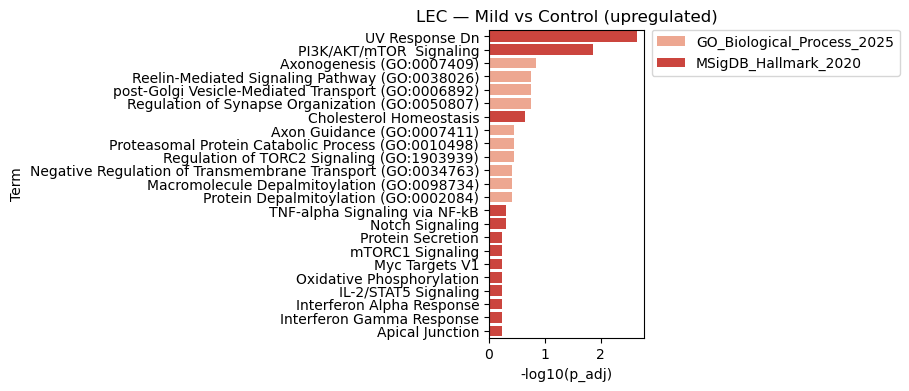

In [13]:
fig_mild_up, sel_mild_up = make_barplot(
    GO_mild_up, Msig_mild_up,
    go_idx=range(0, 10), msig_idx=range(0, 13),
    title="LEC — Mild vs Control (upregulated)",
    savepath=f"{out_base}/LEC_mild_up.pdf",
    figsize=(2, 4)
)

### Downregulated pathways

In [14]:
GO_mild_down   = load_results(f"{out_base}/mild_down", "GO_Biological_Process_2025")
GO_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of DNA-templated Transcription Init...,3/10,0.000170,0.190915,0,0,37.312150,323.92410,SETX;JUN;MITF
1,GO_Biological_Process_2025,"Substrate-Dependent Cell Migration, Cell Exten...",2/6,0.001916,0.464902,0,0,43.346490,271.24370,SDCBP;NTN1
2,GO_Biological_Process_2025,Positive Regulation of Interleukin-5 Productio...,2/6,0.001916,0.464902,0,0,43.346490,271.24370,PDE4D;PRKCZ
3,GO_Biological_Process_2025,Phosphatidylinositol-Mediated Signaling (GO:00...,3/23,0.002243,0.464902,0,0,13.050660,79.60915,PLCG2;PIK3C2G;FGFR1
4,GO_Biological_Process_2025,Cytoskeleton Organization (GO:0007010),6/117,0.002347,0.464902,0,0,4.743967,28.72337,CECR2;FMNL2;PALLD;MICAL3;WDPCP;WASF3
5,GO_Biological_Process_2025,Regulation of Ruffle Assembly (GO:1900027),3/24,0.002542,0.464902,0,0,12.428570,74.25989,EPS8;CAV1;RDX
6,GO_Biological_Process_2025,Regulation of Cardiac Muscle Cell Contraction ...,3/26,0.003210,0.464902,0,0,11.346680,65.14577,CAV1;PDE4D;ANK2
7,GO_Biological_Process_2025,Establishment of Endothelial Barrier (GO:0061028),3/28,0.003977,0.464902,0,0,10.437890,57.69190,PDE4D;RDX;F11R
8,GO_Biological_Process_2025,mRNA Splice Site Recognition (GO:0006376),3/29,0.004399,0.464902,0,0,10.035920,54.45888,SETX;CELF2;LUC7L3
9,GO_Biological_Process_2025,Positive Regulation of Monocyte Differentiatio...,2/9,0.004495,0.464902,0,0,24.765660,133.85540,IL34;ZFP36L1


In [15]:
Msig_mild_down = load_results(f"{out_base}/mild_down", "MSigDB_Hallmark_2020")
Msig_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,9/200,0.000530,0.015903,0,0,4.174528,31.486110,JUN;ECM2;LUM;COL6A2;COL12A1;LAMA3;SLIT3;FSTL1;...
1,MSigDB_Hallmark_2020,Angiogenesis,3/36,0.008104,0.121560,0,0,7.904285,38.062270,LUM;FSTL1;FGFR1
2,MSigDB_Hallmark_2020,Apoptosis,5/161,0.038634,0.386335,0,0,2.794017,9.090710,JUN;DAP;LUM;CAV1;SAT1
3,MSigDB_Hallmark_2020,Inflammatory Response,5/200,0.081598,0.424435,0,0,2.230769,5.590208,MSR1;GPC3;ITGB8;ATP2B1;CD55
4,MSigDB_Hallmark_2020,p53 Pathway,5/200,0.081598,0.424435,0,0,2.230769,5.590208,JUN;RNF19B;CDH13;SAT1;ZFP36L1
5,MSigDB_Hallmark_2020,UV Response Dn,4/144,0.084887,0.424435,0,0,2.481669,6.120871,CAV1;CELF2;ATP2B1;SYNE1
6,MSigDB_Hallmark_2020,Androgen Response,3/100,0.108367,0.464430,0,0,2.680367,5.956394,GUCY1A1;HSD17B14;SAT1
7,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,4/200,0.199091,0.663638,0,0,1.767564,2.852833,JUN;RNF19B;ATP2B1;SAT1
8,MSigDB_Hallmark_2020,KRAS Signaling Up,4/200,0.199091,0.663638,0,0,1.767564,2.852833,SPON1;GUCY1A1;GPNMB;ALDH1A2
9,MSigDB_Hallmark_2020,Interferon Alpha Response,2/97,0.306975,0.809610,0,0,1.816713,2.145518,LGALS3BP;TENT5A


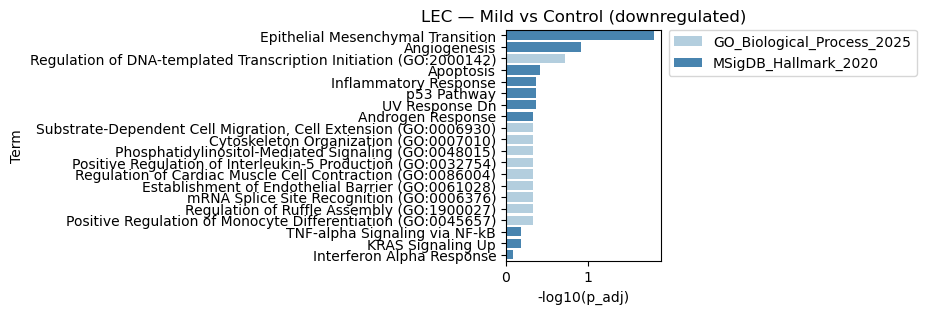

In [16]:
fig_mild_down, sel_mild_down = make_barplot(
    GO_mild_down, Msig_mild_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="LEC — Mild vs Control (downregulated)",
    savepath=f"{out_base}/LEC_mild_down.pdf",
    palette="Blues",
)

## Severe vs control

In [17]:
df_severe = load_dge(dge_folder_severe, cell_type_filename)
df_severe.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Severe,mean_Control
0,XIST,7503.0,2.321525e-15,-0.259152,0.207,0.276,7.225745e-11,0.426971,0.495275
1,RER1,11079.0,1.955950e-10,-0.126957,0.065,0.083,6.087895e-06,0.073331,0.082550
2,PTPRE,5791.0,4.653719e-09,0.644566,0.924,0.774,1.448470e-04,1.540833,1.208119
3,PRXL2A,84293.0,9.353843e-09,1.136077,0.130,0.068,2.911384e-04,0.146356,0.068795
4,AC060780.1,NaN,1.595992e-08,0.799042,0.098,0.053,4.967525e-04,0.093332,0.054848


In [18]:
glist_severe_up, glist_severe_down = get_up_down_genes(df_severe, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Severe vs Control DEGs— up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Severe vs Control DEGs— up: 649, down: 224


  Saved: volcano_LEC_severe_vs_control.pdf


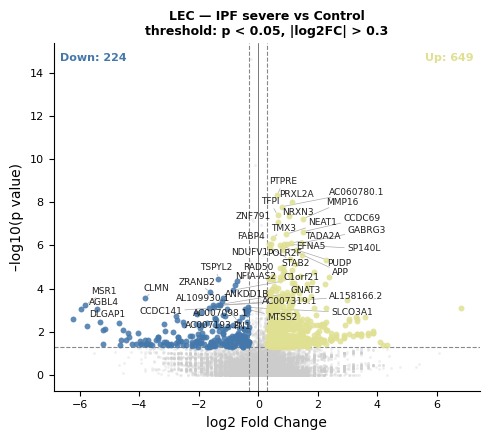

In [19]:
plot_volcano(df_severe, "IPF severe vs Control", save =True, show = True,
             savepath=out_base +"volcano_LEC_severe_vs_control.pdf")

In [20]:
enr_severe_up, enr_severe_down = run_enrichr_up_down(
    glist_severe_up, glist_severe_down,
    outdir_up=f"{out_base}/severe_up",
    outdir_down=f"{out_base}/severe_down",
)

### Upregulated pathways

In [21]:
GO_severe_up   = load_results(f"{out_base}/severe_up", "GO_Biological_Process_2025")
GO_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Positive Regulation of Small GTPase Mediated S...,9/53,0.000047,0.117246,0,0,6.170561,61.53969,NOTCH1;AUTS2;ARHGEF3;ARRB1;ITGAV;TNS3;RTN4;FER...
1,GO_Biological_Process_2025,Regulation of Anatomical Structure Morphogenes...,13/127,0.000252,0.316233,0,0,3.449203,28.58616,GSK3B;MEF2C;POGLUT1;FLT4;RC3H1;VASH1;EFNA5;VPS...
2,GO_Biological_Process_2025,Negative Regulation of Blood Vessel Endothelia...,6/34,0.000706,0.426956,0,0,6.439569,46.72199,MEF2C;NOTCH1;CSNK2B;MMRN2;VASH1;FGF13
3,GO_Biological_Process_2025,Positive Regulation of Cardiac Muscle Cell Pro...,4/14,0.000848,0.426956,0,0,11.994420,84.83178,MEF2C;NOTCH1;FGF13;ZFPM2
4,GO_Biological_Process_2025,Positive Regulation of Rac Protein Signal Tran...,3/7,0.001080,0.426956,0,0,22.461690,153.43990,AUTS2;TNS3;RTN4
5,GO_Biological_Process_2025,Regulation of Cell Junction Assembly (GO:1901888),5/25,0.001097,0.426956,0,0,7.504270,51.14035,MEF2C;NLGN4X;PRKCH;FLOT1;SRGAP2B
6,GO_Biological_Process_2025,Positive Regulation of Intracellular Signal Tr...,36/652,0.001422,0.426956,0,0,1.786138,11.70984,APP;CANT1;CTBP2;SHC1;FLT4;EFNA5;STK4;RTN4;FLOT...
7,GO_Biological_Process_2025,Regulation of Axon Extension (GO:0030516),6/39,0.001494,0.426956,0,0,5.462463,35.54134,GSK3B;ZFYVE27;SEMA3A;MAP3K13;RTN4;DNM2
8,GO_Biological_Process_2025,Negative Regulation of Anoikis (GO:2000811),4/17,0.001866,0.426956,0,0,9.225045,57.96994,NOTCH1;PIK3R3;ITGA5;PTK2
9,GO_Biological_Process_2025,Positive Regulation of Cardiac Muscle Tissue G...,4/17,0.001866,0.426956,0,0,9.225045,57.96994,MEF2C;NOTCH1;FGF13;ZFPM2


In [22]:
Msig_severe_up = load_results(f"{out_base}/severe_up", "MSigDB_Hallmark_2020")
Msig_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Mitotic Spindle,14/199,0.005597,0.145198,0,0,2.284094,11.844240,ARHGEF12;PXN;SHROOM2;ARAP3;CKAP5;LRPPRC;CD2AP;...
1,MSigDB_Hallmark_2020,Angiogenesis,5/36,0.005808,0.145198,0,0,4.838710,24.912260,APP;POSTN;SLCO2A1;ITGAV;PTK2
2,MSigDB_Hallmark_2020,Inflammatory Response,13/200,0.013830,0.230495,0,0,2.094743,8.967463,IL1R1;SPHK1;ATP2A2;ADM;NMI;HIF1A;PTPRE;KLF6;ST...
3,MSigDB_Hallmark_2020,Unfolded Protein Response,8/113,0.030854,0.385675,0,0,2.287616,7.957447,ZBTB17;HSPA5;SHC1;EXOSC9;SRPRA;ATF6;SEC11A;PDIA5
4,MSigDB_Hallmark_2020,Apical Surface,4/44,0.053681,0.388251,0,0,2.993953,8.756403,APP;SHROOM2;EFNA5;SULF2
5,MSigDB_Hallmark_2020,Apical Junction,11/200,0.062120,0.388251,0,0,1.748039,4.857250,ADAMTS5;SHC1;ADAM23;SHROOM2;PIK3R3;PBX2;MYH9;P...
6,MSigDB_Hallmark_2020,Oxidative Phosphorylation,11/200,0.062120,0.388251,0,0,1.748039,4.857250,GLUD1;RHOT2;ALAS1;IDH2;NDUFS4;POLR2F;DLAT;NDUF...
7,MSigDB_Hallmark_2020,p53 Pathway,11/200,0.062120,0.388251,0,0,1.748039,4.857250,APP;PTPRE;CSRNP2;NOTCH1;DRAM1;TCN2;SP1;SPHK1;R...
8,MSigDB_Hallmark_2020,UV Response Dn,8/144,0.097263,0.540348,0,0,1.763329,4.109156,MMP16;ZMIZ1;MGMT;NFIB;PMP22;PIK3R3;NR1D2;TFPI
9,MSigDB_Hallmark_2020,Estrogen Response Early,9/200,0.203328,0.810298,0,0,1.410668,2.247100,REEP1;KDM4B;CANT1;RPS6KA2;NRIP1;ENDOD1;FLNB;RR...


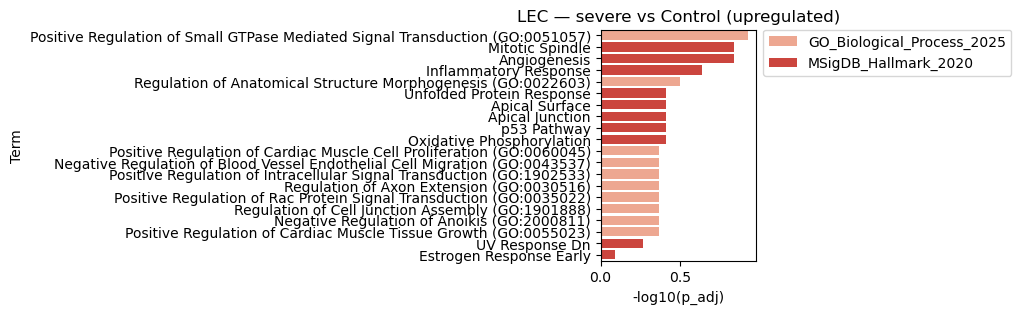

In [23]:
fig_severe_up, sel_severe_up = make_barplot(
    GO_severe_up, Msig_severe_up,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="LEC — severe vs Control (upregulated)",
    savepath=f"{out_base}/LEC_severe_up.pdf",
)

### Downregulated pathways

In [24]:
GO_severe_down   = load_results(f"{out_base}/severe_down", "GO_Biological_Process_2025")
GO_severe_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Antigen Processing and Presentation of Endogen...,2/6,0.001818,0.574652,0,0,44.531530,280.98280,ERAP1;IDE
1,GO_Biological_Process_2025,cAMP-mediated Signaling (GO:0019933),3/24,0.002358,0.574652,0,0,12.769880,77.25615,PDE3B;PDE5A;PDE7A
2,GO_Biological_Process_2025,Response to Glucocorticoid (GO:0051384),3/25,0.002658,0.574652,0,0,12.188810,72.28295,ANXA1;SLIT3;ZFP36L1
3,GO_Biological_Process_2025,Negative Regulation of Mitotic Cell Cycle (GO:...,3/30,0.004503,0.574652,0,0,9.929110,53.64776,TOM1L1;BTG3;ZFP36L1
4,GO_Biological_Process_2025,Carbon Dioxide Transport (GO:0015670),2/11,0.006426,0.574652,0,0,19.786790,99.87184,HBB;RHAG
5,GO_Biological_Process_2025,Extracellular Transport (GO:0006858),2/14,0.010400,0.574652,0,0,14.837840,67.74890,SPEF2;DNAAF4
6,GO_Biological_Process_2025,Gas Transport (GO:0015669),2/15,0.011912,0.574652,0,0,13.695770,60.67503,HBB;RHAG
7,GO_Biological_Process_2025,One-Carbon Compound Transport (GO:0019755),2/16,0.013514,0.574652,0,0,12.716860,54.73349,HBB;RHAG
8,GO_Biological_Process_2025,Peptide Catabolic Process (GO:0043171),2/16,0.013514,0.574652,0,0,12.716860,54.73349,ERAP1;IDE
9,GO_Biological_Process_2025,Cellular Response to Corticosteroid Stimulus (...,2/16,0.013514,0.574652,0,0,12.716860,54.73349,ANXA1;ZFP36L1


In [25]:
Msig_severe_down = load_results(f"{out_base}/severe_down", "MSigDB_Hallmark_2020")
Msig_severe_down.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,8/200,0.001918,0.074816,0,0,3.777778,23.634860,JUN;ECM2;LUM;FN1;PLOD3;SLIT3;SAT1;DCN
1,MSigDB_Hallmark_2020,Apoptosis,6/161,0.009670,0.188568,0,0,3.484049,16.161500,BTG3;JUN;ANXA1;LUM;SAT1;DCN
2,MSigDB_Hallmark_2020,Pancreas Beta Cells,2/40,0.073806,0.873654,0,0,4.679469,12.196140,DPP4;PAK3
3,MSigDB_Hallmark_2020,Pperoxisome,3/104,0.111502,0.873654,0,0,2.644371,5.800999,IDH1;IDE;DHRS3
4,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,4/199,0.184689,0.873654,0,0,1.825734,3.083814,ARL4A;COL6A1;FGL2;DHRS3
5,MSigDB_Hallmark_2020,Hypoxia,4/200,0.186932,0.873654,0,0,1.816327,3.046001,JUN;GPC3;HDLBP;DCN
6,MSigDB_Hallmark_2020,Glycolysis,4/200,0.186932,0.873654,0,0,1.816327,3.046001,IDH1;GPC3;HDLBP;DCN
7,MSigDB_Hallmark_2020,p53 Pathway,4/200,0.186932,0.873654,0,0,1.816327,3.046001,TSPYL2;JUN;SAT1;ZFP36L1
8,MSigDB_Hallmark_2020,Coagulation,3/138,0.201612,0.873654,0,0,1.974962,3.162721,DPP4;ANXA1;FN1
9,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,2/87,0.254736,0.896063,0,0,2.087016,2.854050,JUN;IL7


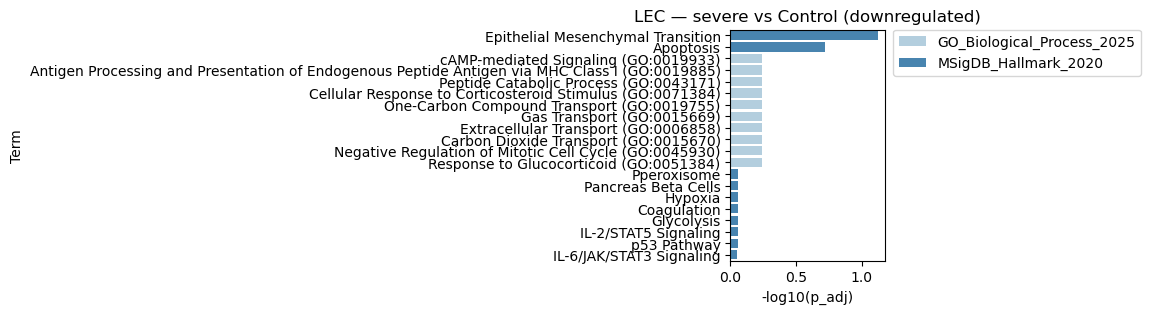

In [26]:
fig_severe_down, sel_severe_down = make_barplot(
    GO_severe_down, Msig_severe_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="LEC — severe vs Control (downregulated)",
    savepath=f"{out_base}/LEC_severe_down.pdf",
    palette="Blues",
)

In [27]:
print(f"Mild vs Control — up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")
print(f"Severe vs Control — up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Mild vs Control — up: 858, down: 230
Severe vs Control — up: 649, down: 224


In [28]:
print("Upregulated genes (Mild vs Control):")
print(glist_mild_up)

Upregulated genes (Mild vs Control):
['XIST', 'NRXN3', 'CMTM8', 'TFPI', 'FBXW5', 'MTSS2', 'TMED8', 'APP', 'NEAT1', 'SEMA3A', 'TXNDC15', 'COMMD4', 'CCL21', 'ITGA9', 'PPM1L', 'TGOLN2', 'SASH1', 'BRD3', 'AL122035.1', 'SPCS1', 'ZNF521', 'MMP16', 'AL078604.4', 'CSRNP2', 'SPRY4-AS1', 'EP300', 'PANK2', 'NOX4', 'AC005037.1', 'ELP1', 'UNC5B', 'AP000525.1', 'SPCS3', 'PHC1', 'KRAS', 'CEACAM19', 'LINC02802', 'OSBP2', 'MKRN1', 'KLHL2', 'SRSF4', 'RANBP10', 'ADAMTS15', 'NOCT', 'NINL', 'VDAC1', 'WDYHV1', 'TSC2', 'GRAP', 'CATSPERB', 'SLC25A51', 'RELN', 'CXorf38', 'HIF3A', 'BTN3A3', 'INAFM1', 'ATP11A', 'DPAGT1', 'GPM6B', 'EPHB1', 'HACD1', 'PRPF8', 'REEP1', 'PRKG1', 'KANSL1', 'ZNF276', 'PRKCA', 'SYNJ2', 'NFE2L2', 'ROBO4', 'RASAL2', 'GNG12', 'AC011824.2', 'OLFML2A', 'CASTOR3', 'SCARF1', 'RNF130', 'AL021368.2', 'ZMIZ1', 'CTTNBP2NL', 'AC130324.2', 'SV2B', 'RBM3', 'SRI', 'FAM221A', 'TXNL4B', 'REC114', 'SLC35D1', 'EMID1', 'FDFT1', 'DIPK2B', 'FLRT2', 'TFB1M', 'ZNF461', 'CTR9', 'TOR1AIP2', 'ZNF720', 'PGGT1B', '

In [29]:
print("Upregulated genes (Severe vs Control):")
print(glist_severe_up)

Upregulated genes (Severe vs Control):
['PTPRE', 'PRXL2A', 'AC060780.1', 'TFPI', 'NRXN3', 'MMP16', 'ZNF791', 'CCDC69', 'NEAT1', 'TMX3', 'GABRG3', 'TADA2A', 'FABP4', 'NDUFV1', 'SP140L', 'EFNA5', 'APP', 'POLR2F', 'STAB2', 'PUDP', 'ITGA9', 'SV2B', 'ZNF385D', 'UNC5B', 'PLA2R1', 'PALD1', 'TXNRD3', 'EPHB1', 'CSRNP2', 'OSBPL3', 'ZNF521', 'GNG12', 'NOTCH1', 'RGL2', 'EEF1E1', 'EGFL7', 'SLC9A9', 'SH3BP2', 'BACE2', 'CCDC7', 'THOC1', 'UTRN', 'RPS6KA2', 'ATG3', 'AC022893.1', 'ADAMTS15', 'ADAM23', 'FAM66C', 'RASGRP3', 'C21orf91', 'AL021368.2', 'FLRT2', 'PTK2', 'GRAMD1C', 'HUS1', 'CHST15', 'ZNF276', 'ATP2A2', 'C5orf63', 'GRAP', 'OSBP2', 'PDE7B', 'SHE', 'BCL7B', 'APOL3', 'SH2D3C', 'MRPS35', 'ARRDC4', 'SULF2', 'RAPGEF4', 'KLHL5', 'AL050309.1', 'FBXL7', 'TTC7B', 'ALPK1', 'SLC38A1', 'ZNF121', 'PALM2-AKAP2', 'NINL', 'DLGAP2', 'MAPK8', 'VASH1', 'DRAM1', 'MAGOH', 'A4GALT', 'ATL1', 'DISP1', 'DIPK2B', 'ARRDC3-AS1', 'ROBO4', 'STAU2', 'SASH1', 'CLEC1A', 'SENP5', 'TRAPPC9', 'ITGA5', 'SPTBN1', 'PRKD1', 'SLC35B4',

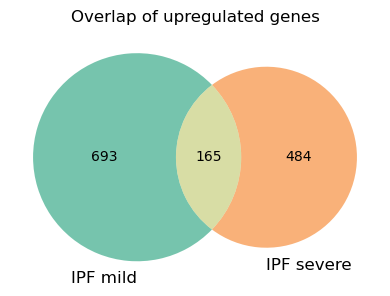

Overlap genes: 165
['AATF', 'ABHD17C', 'AC002072.1', 'AC012615.1', 'AC119674.1', 'ADAM19', 'ADAMTS15', 'ADGRG3', 'AL021368.2', 'AL161457.1', 'AL590226.1', 'APP', 'ARG2', 'ARHGEF28', 'ARID1B', 'ARL6IP5', 'ARRB1', 'ATF7', 'ATG3', 'ATP11A', 'BCAS2', 'BCL7C', 'BMI1', 'BTN3A2', 'C21orf91', 'C9orf85', 'CACUL1', 'CATSPERB', 'CCL21', 'CCT3', 'CEMIP2', 'CEP350', 'CHST15', 'CLEC1A', 'COL23A1', 'COX16', 'CPNE5', 'CRY2', 'CSNK2B', 'CSRNP2', 'CTBP2', 'CXorf38', 'DDX54', 'DIPK2B', 'DISP1', 'DLAT', 'DRAM1', 'DTNB', 'DYNC1I1', 'EEF1E1', 'EFNA5', 'EGFL7', 'EMID1', 'EPHB1', 'EXD3', 'FAM66C', 'FBXO28', 'FLOT1', 'FLRT2', 'FOCAD', 'FRMD6', 'FZD4', 'GALNT15', 'GBA2', 'GEMIN5', 'GFOD1', 'GFOD2', 'GGCT', 'GNG12', 'GNG7', 'GRAMD1C', 'GRAP', 'GRIN2B', 'IL32', 'INO80C', 'IQSEC1', 'ITGA9', 'KANK3', 'KLHL2', 'KLHL5', 'KRAS', 'LIG3', 'LINC01128', 'LINC02840', 'MAGOH', 'MAP3K13', 'MAP4K4', 'MAPKBP1', 'MARCH3', 'MARCH8', 'MMP16', 'MPZL1', 'MRPS35', 'MYH9', 'NEAT1', 'NFE2L1', 'NFIB', 'NINL', 'NLGN4X', 'NOX4', 'NRXN3',

In [31]:
from matplotlib_venn import venn2
mild_up = set(glist_mild_up)
severe_up = set(glist_severe_up)

overlap_genes = mild_up & severe_up

plt.figure(figsize=(4, 4))

venn2(
    [mild_up, severe_up],
    set_labels=("IPF mild", "IPF severe"),
    set_colors=("#1B9E77", "#F57E20"),
    alpha=0.6,
)

plt.title("Overlap of upregulated genes")
plt.tight_layout()
# Save the figure
plt.savefig(out_base + "venn_upregulated_genes.pdf", bbox_inches="tight")
plt.show()

print(f"Overlap genes: {len(overlap_genes)}")
print(sorted(overlap_genes))